<a href="https://colab.research.google.com/github/litlig/notebooks/blob/main/guided_2d_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guided diffusion model from scratch

### Problem framing

In unguided diffusion model, we sample a noise image and follow the diffusion process to arrive at an image. Many times, we want to prompt a model to generate an image, such generation is called guided generation.

Here we continue using the 2-dimension example, a two-pixel image. We say the collection on the upper right are cat images, and lower left are dog images.

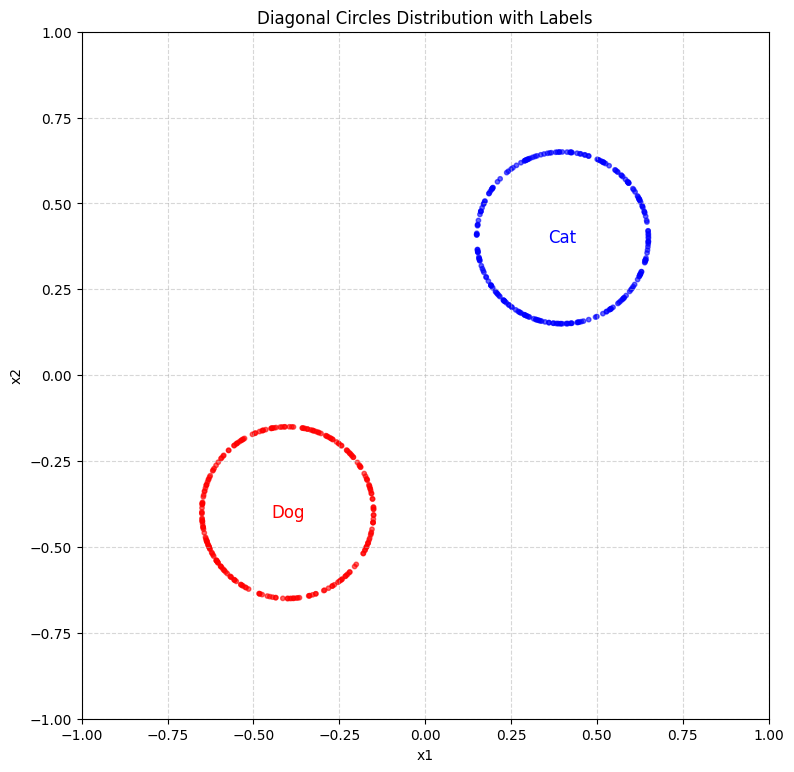

In [2]:
# @title 2D distribution example with text label
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple


def diagonal_circles_distribution(batch_size: int = 1) -> Tuple[np.ndarray, np.ndarray]:
  # Create two circles
  n_per_circle = batch_size // 2
  t = 2 * np.pi * np.random.rand(batch_size)
  r = 0.25

  centers = np.zeros((batch_size, 2))
  centers[:n_per_circle, :] = -0.4 # Center for 'Dog'
  centers[n_per_circle:, :] = 0.4  # Center for 'Cat'

  x1 = centers[:, 0] + r * np.cos(t)
  x2 = centers[:, 1] + r * np.sin(t)

  points = np.stack([x1, x2], axis=-1)

  # Create labels: 0 for dog, 1 for cat
  labels = np.zeros(batch_size, dtype=int)
  labels[n_per_circle:] = 1

  return points, labels

def plot_diagonal_circles_with_labels(dist_fn):
  fig, ax = plt.subplots(1, 1, figsize=(8, 8))
  samples, labels = dist_fn(500)

  # Map integer labels to colors consistent with text annotations
  color_map = {0: 'red', 1: 'blue'} # Dog is red, Cat is blue
  point_colors = np.array([color_map[label] for label in labels])

  ax.scatter(samples[:, 0], samples[:, 1], c=point_colors, alpha=0.6, s=10)
  ax.set_xlabel('x1')
  ax.set_ylabel('x2')
  ax.set_title('Diagonal Circles Distribution with Labels')
  ax.set_xlim([-1, 1])
  ax.set_ylim([-1, 1])
  ax.grid(True, linestyle='--', alpha=0.5)
  ax.set_aspect('equal')

  # Add text labels 'Dog' and 'Cat'
  ax.text(-0.4, -0.4, 'Dog', color='red', fontsize=12, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
  ax.text(0.4, 0.4, 'Cat', color='blue', fontsize=12, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

  plt.tight_layout()
  plt.show()

# Call the new plotting function
plot_diagonal_circles_with_labels(diagonal_circles_distribution)

### Vanilla guidance
With text label/prompt y, we want to learn a guided **vector field** that moves the probability mass towards the probability distribution of image conditioned on the label prompt, p_data(*|y).

Intuitively, we can follow the same process as the unguided flow matching. For each sample, we sample a pair of image and label (or text caption). We train a nerual network to estimate the conditioned vector field, which also takes the label y as an additional input. The loss function is still the mean square error:

$$\min_{\theta} \mathbb{E}_{t \sim unif(0,1), z,y \sim p_{data}, x \sim p(*|z)} \| f_t^\theta(x, y) - v_t(x|z) \|^2$$


When targe z is given, the conditional vector field can be calculated the same as before:

$$v_t(x|z) = \dot{a_t}x_0 + \dot{b_t}z$$


In [17]:
# @title Train a nn to estimate the vector field
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConditionalFlowModel(nn.Module):
  def __init__(self, embedding_dim=2, num_classes=2):
    super().__init__()
    self.embedding = nn.Embedding(num_classes, embedding_dim) # For labels 0, 1, and 2 (null)
    # Input size: 2 (for xt) + 1 (for t) + embedding_dim (for y)
    input_size = 2 + 1 + embedding_dim
    self.net = nn.Sequential(
        nn.Linear(input_size, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 2),
    )

  def forward(self, xt, t, y):
    y_embedded = self.embedding(y.squeeze(-1)) # Squeeze y to (batch_size,) for embedding
    model_input = torch.cat([xt, t, y_embedded], dim=-1)
    return self.net(model_input)

def get_batch(dist_fn, batch_size):
  z, y = dist_fn(batch_size)
  z = torch.from_numpy(z).float()
  y = torch.from_numpy(y).long()
  x0 = torch.randn(batch_size, 2)
  t = torch.rand(batch_size, 1)
  xt = (1-t) * x0 + t * z
  vf = z - x0
  return xt, t, y, vf

def loss_fn(dist_fn, model, batch_size):
  xt, t, y, vf = get_batch(dist_fn, batch_size)
  vf_pred = model(xt, t, y)
  return F.mse_loss(vf_pred, vf)

def train(dist_fn, num_epochs=10000, batch_size=256, lr=0.001, plot_loss=True):
  # Increased capacity: wider and deeper to handle multi-modality
  model = ConditionalFlowModel()

  optimizer = torch.optim.Adam(model.parameters(), lr)
  losses = []

  for epoch in range(num_epochs):
    optimizer.zero_grad()
    loss = loss_fn(dist_fn, model, batch_size)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 1000 == 0:
      print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

  if plot_loss:
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.yscale('log')
    plt.title('Training Loss')
    plt.show()

  return model

print("Training for diagonal circles example...")
circ_model = train(diagonal_circles_distribution, plot_loss=False)

Training for diagonal circles example...
Epoch 0, Loss: 1.139182
Epoch 1000, Loss: 0.337194
Epoch 2000, Loss: 0.350622
Epoch 3000, Loss: 0.300851
Epoch 4000, Loss: 0.310820
Epoch 5000, Loss: 0.239098
Epoch 6000, Loss: 0.249217
Epoch 7000, Loss: 0.252103
Epoch 8000, Loss: 0.271696
Epoch 9000, Loss: 0.221580


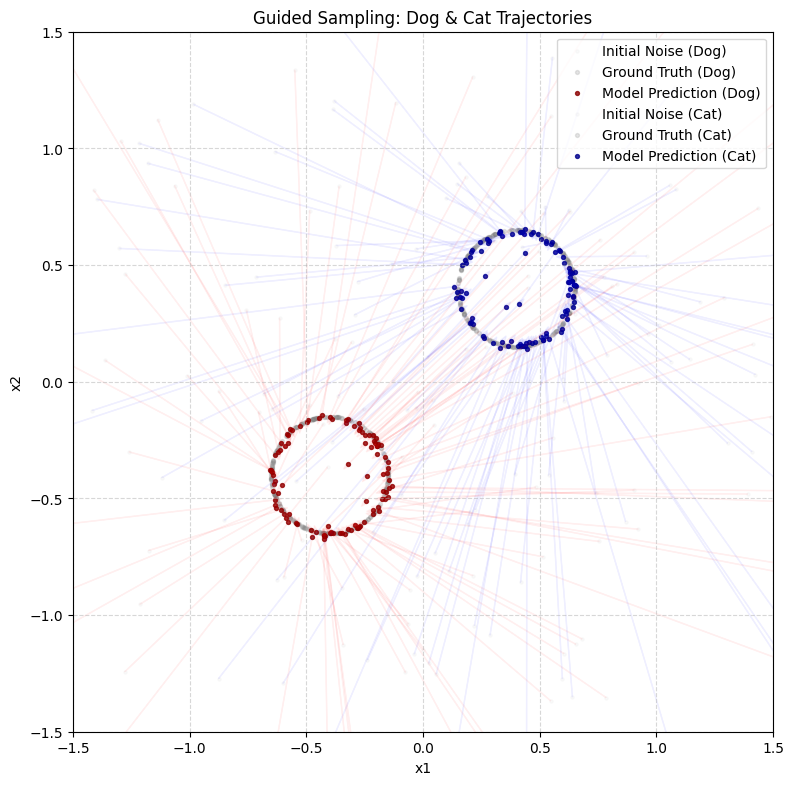

In [18]:
# @title guided sampling using trained nn
def sample_with_guide(model, nsample, steps=100, guide_label=0):
  model.eval()
  with torch.no_grad():
    x_0 = torch.randn(nsample, 2)
    x = x_0.clone()
    dt = 1.0 / steps

    # Prepare the guidance label tensor
    # It will be a tensor of shape (nsample, 1) with all values equal to guide_label
    y_guide = torch.full((nsample, 1), np.long(guide_label))

    for step in range(steps):
      t = (step / steps) * torch.ones(nsample, 1)
      vf = model(x, t, y_guide)
      x = x + vf * dt
  return x_0.cpu().numpy(), x.cpu().numpy()

def compare_all_results(circ_model, n_samples=100):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8)) # Single subplot

    # Get all ground truth data once to filter for dog and cat
    full_gt_points, full_gt_labels = diagonal_circles_distribution(500)

    # Filter ground truth for dog specific points (label 0)
    gt_dog = full_gt_points[full_gt_labels == 0]
    # Perform guided sampling for Dog (label 0)
    noise_dog, pred_dog = sample_with_guide(circ_model, n_samples, guide_label=0)

    # Filter ground truth for cat specific points (label 1)
    gt_cat = full_gt_points[full_gt_labels == 1]
    # Perform guided sampling for Cat (label 1)
    noise_cat, pred_cat = sample_with_guide(circ_model, n_samples, guide_label=1)

    # Plot Dog results
    ax.scatter(noise_dog[:, 0], noise_dog[:, 1], alpha=0.1, s=5, label='Initial Noise (Dog)', color='lightgray')
    ax.scatter(gt_dog[:, 0], gt_dog[:, 1], alpha=0.2, s=8, label='Ground Truth (Dog)', color='grey')
    ax.scatter(pred_dog[:, 0], pred_dog[:, 1], alpha=0.8, s=8, label='Model Prediction (Dog)', color='darkred')

    # Plot Cat results
    ax.scatter(noise_cat[:, 0], noise_cat[:, 1], alpha=0.1, s=5, label='Initial Noise (Cat)', color='lightgray') # Initial noise from cat is same as dog
    ax.scatter(gt_cat[:, 0], gt_cat[:, 1], alpha=0.2, s=8, label='Ground Truth (Cat)', color='grey')
    ax.scatter(pred_cat[:, 0], pred_cat[:, 1], alpha=0.8, s=8, label='Model Prediction (Cat)', color='darkblue')

    # Draw arrows for Dog trajectories
    for i in range(n_samples):
        ax.arrow(noise_dog[i, 0], noise_dog[i, 1],
                      pred_dog[i, 0] - noise_dog[i, 0],
                      pred_dog[i, 1] - noise_dog[i, 1],
                      color='red', alpha=0.05, head_width=0.02)

    # Draw arrows for Cat trajectories
    for i in range(n_samples):
        ax.arrow(noise_cat[i, 0], noise_cat[i, 1],
                      pred_cat[i, 0] - noise_cat[i, 0],
                      pred_cat[i, 1] - noise_cat[i, 1],
                      color='blue', alpha=0.05, head_width=0.02)

    # Common plot settings
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_aspect('equal')
    ax.set_title('Guided Sampling: Dog & Cat Trajectories')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

compare_all_results(circ_model)

### Classifier-Free Guidance
In this simple example, the above vanilla approach on guided generation works well. However, the generated images do not follow the prompt or label very well empirically. The guided probability path is $p_t(x|y)$. Based on Bayes therom:

$$p_t(x|y)=p_t(y|x) * p_t(x) / p_t(y)$$

Now take log on both sides and then take derivitive with respect to x, we get
$$∇logp_t(x|y) = ∇logp_t(y|x) + ∇logp_t(x)$$

$∇log$ is the score function. For Gaussian probability path, we know that vector field $v_t(x)=α_t ∇log(p_t(x)) + \beta_tx_t$. Therefore, we get a formula that connects two vector field

$$v_t(x|y) = v_t(x) + α ∇logp_t(y|x)$$

$∇logp_t(y|x)$ is the term that contributed to the guided part, a nature to make generation follows guide better, we need to scale it up. $p_t(y|x) is basically the problem of classification given a noise data x, therefore this approach is classifier guidance since it requires training a nn for vector field and another classifier.

A more elegant approach eliminates the need of training additional classifier. Given the guided vector field $v_t(x|y)$ and unguided vector field $v_t(x)$, the influence of guidance is $v_t(x|y)-v_t(x)$, we can scale it up by multiplying a weight w greater than 1, and use the following in forward sampling:

$$(1-w)v_t(x) + w v_t(x|y)$$

To get both $v_t(x)$ and $v_t(x|y) in one nn traing, we say the unguided vector field is same as a guided vector but with a special null prompt, which is injected randomly in training samples.

In [11]:
# @title Classifier-free guidance training
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_batch(dist_fn, batch_size, inject_rate=0.1):
  z, y = dist_fn(batch_size)
  z = torch.from_numpy(z).float()
  y = torch.from_numpy(y).long().unsqueeze(1) # Ensure y is long for embedding
  x0 = torch.randn(batch_size, 2)
  t = torch.rand(batch_size, 1)
  xt = (1-t) * x0 + t * z
  vf = z - x0

  # Select 0.1*batch_size randomly and set y to 2 for classification-free guidance
  num_inject = int(batch_size * inject_rate)
  if num_inject > 0:
    inject_indices = torch.randperm(batch_size)[:num_inject]
    y[inject_indices] = 2 # Set to a special 'null' label

  return xt, t, y, vf


def loss_fn(dist_fn, model, batch_size):
  xt, t, y, vf = get_batch(dist_fn, batch_size)
  vf_pred = model(xt, t, y)
  return F.mse_loss(vf_pred, vf)

def train(dist_fn, num_epochs=10000, batch_size=256, lr=0.001, plot_loss=True):
  # Initialize the custom model
  model = ConditionalFlowModel(num_classes=3) # num_classes=3 for 0, 1, and 2 (null)

  optimizer = torch.optim.Adam(model.parameters(), lr)
  losses = []

  for epoch in range(num_epochs):
    optimizer.zero_grad()
    loss = loss_fn(dist_fn, model, batch_size)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 1000 == 0:
      print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

  if plot_loss:
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.yscale('log')
    plt.title('Training Loss')
    plt.show()

  return model

print("Training for diagonal circles example...")
circ_model = train(diagonal_circles_distribution, plot_loss=False)

Training for diagonal circles example...
Epoch 0, Loss: 1.097157
Epoch 1000, Loss: 0.326804
Epoch 2000, Loss: 0.308776
Epoch 3000, Loss: 0.323560
Epoch 4000, Loss: 0.246554
Epoch 5000, Loss: 0.281876
Epoch 6000, Loss: 0.271702
Epoch 7000, Loss: 0.262463
Epoch 8000, Loss: 0.266187
Epoch 9000, Loss: 0.239501


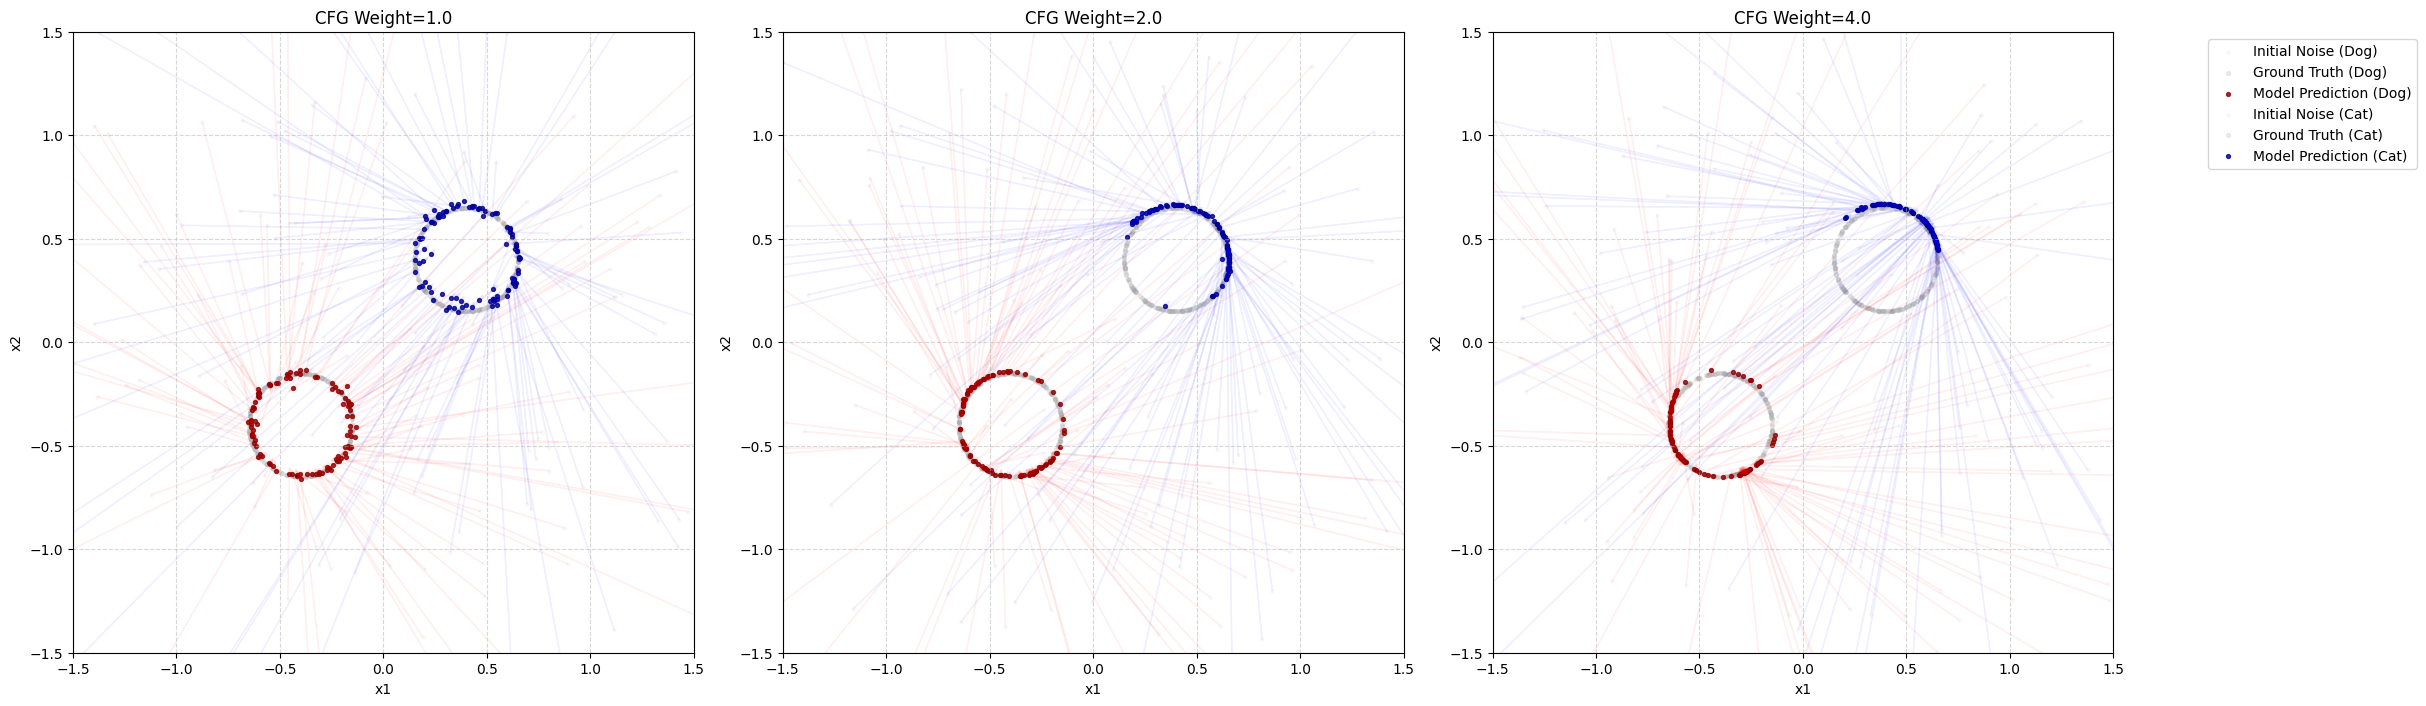

In [14]:
# @title Classifier-free guided sampling
import numpy as np
import torch
import matplotlib.pyplot as plt

def cfg_sample(model, nsample, steps=100, guide_label=0, weight = 2.0):
  special_label = 2
  model.eval()
  with torch.no_grad():
    x_0 = torch.randn(nsample, 2)
    x = x_0.clone()
    dt = 1.0 / steps

    # Prepare the guidance label tensor
    # It will be a tensor of shape (nsample, 1) with all values equal to guide_label
    y_guide = torch.full((nsample, 1), guide_label, dtype=torch.long) # Cast to long

    for step in range(steps):
      t = (step / steps) * torch.ones(nsample, 1)
      # Concatenate x, t, and y_guide as input to the model
      vf_guided = model(x, t, y_guide)
      vf_unguided = model(x, t, torch.full((nsample, 1), special_label, dtype=torch.long)) # Cast to long
      x = x + ((1-weight) * vf_unguided + weight * vf_guided) * dt
  return x_0.cpu().numpy(), x.cpu().numpy()

def compare_cfg_results(circ_model, n_samples=100, weights=[1.0, 2.0, 4.0]):
    fig, axes = plt.subplots(1, len(weights), figsize=(8 * len(weights), 8))
    if len(weights) == 1:
        axes = [axes] # Ensure axes is iterable even for a single subplot

    # Get all ground truth data once to filter for dog and cat
    full_gt_points, full_gt_labels = diagonal_circles_distribution(500)

    # Filter ground truth for dog specific points (label 0)
    gt_dog = full_gt_points[full_gt_labels == 0]
    # Filter ground truth for cat specific points (label 1)
    gt_cat = full_gt_points[full_gt_labels == 1]

    for i, weight in enumerate(weights):
        ax = axes[i]

        # Perform guided sampling for Dog (label 0)
        noise_dog, pred_dog = cfg_sample(circ_model, n_samples, guide_label=0, weight=weight)
        # Perform guided sampling for Cat (label 1)
        noise_cat, pred_cat = cfg_sample(circ_model, n_samples, guide_label=1, weight=weight)

        # Plot Dog results
        ax.scatter(noise_dog[:, 0], noise_dog[:, 1], alpha=0.1, s=5, label='Initial Noise (Dog)', color='lightgray')
        ax.scatter(gt_dog[:, 0], gt_dog[:, 1], alpha=0.2, s=8, label='Ground Truth (Dog)', color='darkgray')
        ax.scatter(pred_dog[:, 0], pred_dog[:, 1], alpha=0.8, s=8, label='Model Prediction (Dog)', color='darkred')

        # Plot Cat results
        ax.scatter(noise_cat[:, 0], noise_cat[:, 1], alpha=0.1, s=5, label='Initial Noise (Cat)', color='lightgray')
        ax.scatter(gt_cat[:, 0], gt_cat[:, 1], alpha=0.2, s=8, label='Ground Truth (Cat)', color='darkgray')
        ax.scatter(pred_cat[:, 0], pred_cat[:, 1], alpha=0.8, s=8, label='Model Prediction (Cat)', color='darkblue')

        # Draw arrows for Dog trajectories
        for k in range(n_samples):
            ax.arrow(noise_dog[k, 0], noise_dog[k, 1],
                          pred_dog[k, 0] - noise_dog[k, 0],
                          pred_dog[k, 1] - noise_dog[k, 1],
                          color='red', alpha=0.05, head_width=0.02)

        # Draw arrows for Cat trajectories
        for k in range(n_samples):
            ax.arrow(noise_cat[k, 0], noise_cat[k, 1],
                          pred_cat[k, 0] - noise_cat[k, 0],
                          pred_cat[k, 1] - noise_cat[k, 1],
                          color='blue', alpha=0.05, head_width=0.02)

        # Common plot settings
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_xlim([-1.5, 1.5])
        ax.set_ylim([-1.5, 1.5])
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_aspect('equal')
        ax.set_title(f'CFG Weight={weight}')
        if i == len(weights) - 1: # Only show legend on the last subplot to avoid redundancy
            ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1))

    plt.tight_layout()
    plt.show()

# Example usage of the new plotting function
compare_cfg_results(circ_model, weights=[1.0, 2.0, 4.0])